# IV inversion: Schadner's explicit inverse-Gaussian quantile

Rebuilds the parity-blended unified call price from `eda_quarterly_unified_iv_bisection.ipynb`, then solves for IV using the closed-form quantile formula from Wolfgang Schadner, *"An Explicit Solution to Black–Scholes Implied Volatility"* (arXiv:2604.24480v4, 2026), benchmarked against the bisection baseline on the same four quarterly `max_*` files.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm, invgauss

DATA_DIR = Path("data")

FILES = {
    "Q1 (2023-01-04)": DATA_DIR / "max_spx_options_filtered_2023-01-04.csv",
    "Q2 (2023-06-30)": DATA_DIR / "max_spx_options_filtered_2023-06-30.csv",
    "Q3 (2023-08-15)": DATA_DIR / "max_spx_options_filtered_2023-08-15.csv",
    "Q4 (2023-11-14)": DATA_DIR / "max_spx_options_filtered_2023-11-14.csv",
}

frames = []
for label, path in FILES.items():
    df = pd.read_csv(path)
    df["quarter"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data["moneyness"] = data["strike"] / data["underlying_last"]

## Pair calls and puts, compute the unified price

Same pipeline as the bisection notebook: pair each call with its put on `(quarter, strike, expire_date)`, build the parity-implied call price from the put, and average it with the call mid.

In [2]:
risk_free_rate = 0.05
dividend_yield = 0.00

calls = data[data["option_type"] == "call"]
puts = data[data["option_type"] == "put"]

pairs = calls.merge(
    puts,
    on=["quarter", "strike", "expire_date", "underlying_last", "dte"],
    suffixes=("_call", "_put"),
)

pairs["call_mid"] = (pairs["bid_call"] + pairs["ask_call"]) / 2
pairs["put_mid"] = (pairs["bid_put"] + pairs["ask_put"]) / 2
pairs["time_to_expiry"] = pairs["dte"] / 365

pairs["parity_call_mid"] = (
    pairs["put_mid"]
    + pairs["underlying_last"] * np.exp(-dividend_yield * pairs["time_to_expiry"])
    - pairs["strike"] * np.exp(-risk_free_rate * pairs["time_to_expiry"])
)
pairs["unified_call_price"] = (pairs["call_mid"] + pairs["parity_call_mid"]) / 2
pairs["moneyness"] = pairs["strike"] / pairs["underlying_last"]

## Baseline: Black-Scholes pricer and bisection solver

Copied from the bisection notebook, unmodified, as the accuracy and speed baseline.

In [3]:
def black_scholes_call(spot, strike, time_to_expiry, volatility, rate, dividend):
    """Return the Black-Scholes European call price."""
    if time_to_expiry <= 0:
        return max(spot - strike, 0.0)

    volatility_sqrt_time = volatility * np.sqrt(time_to_expiry)
    d1 = (
        np.log(spot / strike)
        + (rate - dividend + 0.5 * volatility ** 2) * time_to_expiry
    ) / volatility_sqrt_time
    d2 = d1 - volatility_sqrt_time

    return (
        spot * np.exp(-dividend * time_to_expiry) * norm.cdf(d1)
        - strike * np.exp(-rate * time_to_expiry) * norm.cdf(d2)
    )


def _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
    """Shared no-arbitrage pre-check used by every solver below."""
    if any(pd.isna(v) for v in (target_price, spot, strike, time_to_expiry)) or time_to_expiry <= 0:
        return False
    discounted_spot = spot * np.exp(-dividend * time_to_expiry)
    discounted_strike = strike * np.exp(-rate * time_to_expiry)
    lower_bound = max(discounted_spot - discounted_strike, 0.0)
    upper_bound = discounted_spot
    return (target_price >= lower_bound - tolerance) and (target_price <= upper_bound + tolerance)


def implied_volatility_bisection(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    lower_volatility=1e-6,
    upper_volatility=1.0,
    tolerance=1e-6,
    max_iterations=100,
):
    """Solve for call IV with bisection; return NaN if no valid bracket exists."""
    if not _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
        return np.nan

    low = lower_volatility
    high = upper_volatility
    low_price = black_scholes_call(spot, strike, time_to_expiry, low, rate, dividend)
    high_price = black_scholes_call(spot, strike, time_to_expiry, high, rate, dividend)

    if target_price < low_price - tolerance or target_price > high_price + tolerance:
        return np.nan

    for _ in range(max_iterations):
        midpoint = (low + high) / 2
        midpoint_price = black_scholes_call(
            spot, strike, time_to_expiry, midpoint, rate, dividend
        )
        price_error = midpoint_price - target_price

        if abs(price_error) < tolerance:
            return midpoint
        if price_error < 0:
            low = midpoint
        else:
            high = midpoint

    return (low + high) / 2

## Schadner's explicit solution

The paper's insight: a normalized Black-Scholes call price is a probability on the *variance* scale, specifically the survival function of an inverse Gaussian law. Inverting that identity turns implied volatility into a quantile, evaluated once, with no root-finding loop.

**Normalization.** With discount factor $D = e^{-rT}$, forward $F = S e^{(r-q)T}$, log-moneyness $k = \ln(K/F)$, and normalized call price $c = C/(DF)$:

$$
\sigma(k, c) = \frac{2}{\sqrt{T}} \cdot \frac{1}{\sqrt{\mathcal{F}^{-1}_{IG}\!\left(\frac{1-c}{\eta_k}; \frac{2}{|k|}, 1\right)}}, \qquad \eta_k = \min(1, e^k)
$$

where $\mathcal{F}^{-1}_{IG}(\cdot;\mu,\lambda)$ is the quantile function of the inverse Gaussian distribution with mean $\mu$ and shape $\lambda$ (Chhikara-Folks parametrization), and $\eta_k$ just folds the in-the-money case back onto the out-of-the-money formula via put-call parity. At $k=0$ (exactly at the forward) the formula collapses to the already-known closed form $\sigma = (2/\sqrt{T})\,\Phi^{-1}((1+c)/2)$.

**Mapping to scipy.** `scipy.stats.invgauss` uses a different parametrization (shape `mu`, with `scale`). Matching moments shows `IG(μ, λ)` in the paper's convention equals `invgauss(mu=μ/λ, scale=λ)` in scipy's — and since the paper always uses $\lambda=1$, that's just `invgauss(mu=μ)` with the default `scale=1`.

**What "explicit" means here.** There's no Newton or bisection loop over the Black-Scholes price — one quantile evaluation replaces the entire iteration. The quantile function itself is still evaluated numerically (scipy calls into a Boost root-finder under the hood), so this isn't zero computation — it's one well-conditioned evaluation instead of a multi-step search. The paper's own benchmark (machine-precision accuracy, ~3x faster than Jackel's *Let's Be Rational*) uses a hand-written rational seed plus a single Halley step in C++, not `scipy.stats.invgauss`; the comparison below measures this notebook's scipy-based implementation, not the paper's own tuned one.

In [4]:
def implied_volatility_schadner(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    tolerance=1e-6,
):
    """Solve for call IV via Schadner's explicit inverse-Gaussian quantile formula."""
    # Without this, a price just below intrinsic value (common on thin, wide-spread
    # quotes) still maps to a probability inside (0, 1) after clipping below, and the
    # quantile formula would silently return a number for a price no volatility can
    # produce, instead of correctly reporting that no solution exists.
    if not _price_bounds_valid(target_price, spot, strike, time_to_expiry, rate, dividend, tolerance):
        return np.nan

    discount = np.exp(-rate * time_to_expiry)
    forward = spot * np.exp((rate - dividend) * time_to_expiry)
    normalized_price = target_price / (discount * forward)
    log_moneyness = np.log(strike / forward)

    if abs(log_moneyness) < 1e-10:
        return (2 / np.sqrt(time_to_expiry)) * norm.ppf((1 + normalized_price) / 2)

    eta_k = min(1.0, np.exp(log_moneyness))
    probability = (1 - normalized_price) / eta_k
    # Floating-point roundoff can push this a hair past [0, 1]; invgauss.ppf requires
    # the open interval, and a true no-arbitrage violation is already ruled out by
    # construction since normalized_price is derived from a real market price.
    probability = min(max(probability, 1e-14), 1 - 1e-14)
    mean_param = 2 / abs(log_moneyness)

    quantile = invgauss.ppf(probability, mu=mean_param)
    if not np.isfinite(quantile) or quantile <= 0:
        return np.nan
    return (2 / np.sqrt(time_to_expiry)) / np.sqrt(quantile)

### Vectorized version

`implied_volatility_schadner` above is scalar, called once per row via `pairs.apply(axis=1)` — that loop is pure Python/pandas overhead on top of a call (`invgauss.ppf`) that's already vectorized in C. Passing it numpy arrays directly, once, skips that overhead entirely. Same formula, same no-arbitrage guard, just array-shaped instead of row-shaped.

In [5]:
def implied_volatility_schadner_vectorized(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    tolerance=1e-6,
):
    """Array-valued version of implied_volatility_schadner; same formula, no per-row loop."""
    target_price = np.asarray(target_price, dtype=float)
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    time_to_expiry = np.asarray(time_to_expiry, dtype=float)

    discounted_spot = spot * np.exp(-dividend * time_to_expiry)
    discounted_strike = strike * np.exp(-rate * time_to_expiry)
    lower_bound = np.maximum(discounted_spot - discounted_strike, 0.0)
    upper_bound = discounted_spot
    valid = (
        (time_to_expiry > 0)
        & (target_price >= lower_bound - tolerance)
        & (target_price <= upper_bound + tolerance)
    )

    discount = np.exp(-rate * time_to_expiry)
    forward = spot * np.exp((rate - dividend) * time_to_expiry)
    normalized_price = target_price / (discount * forward)
    log_moneyness = np.log(strike / forward)
    at_the_money = np.abs(log_moneyness) < 1e-10

    eta_k = np.minimum(1.0, np.exp(log_moneyness))
    probability = (1 - normalized_price) / eta_k
    probability = np.clip(probability, 1e-14, 1 - 1e-14)
    mean_param = 2 / np.abs(np.where(at_the_money, 1.0, log_moneyness))

    quantile = invgauss.ppf(probability, mu=mean_param)
    off_the_forward_iv = (2 / np.sqrt(time_to_expiry)) / np.sqrt(quantile)
    at_the_forward_iv = (2 / np.sqrt(time_to_expiry)) * norm.ppf((1 + normalized_price) / 2)
    sigma = np.where(at_the_money, at_the_forward_iv, off_the_forward_iv)

    return np.where(valid & np.isfinite(sigma) & (sigma > 0), sigma, np.nan)

## Solve with both, timed

Bisection still runs row-by-row, since its loop has to early-exit per row on convergence — that's inherent to the algorithm, not something `.apply` is adding on top. Schadner's explicit formula has no such loop, so it runs as one vectorized call over the whole dataset.

In [6]:
solver_args = lambda row: dict(
    target_price=row["unified_call_price"],
    spot=row["underlying_last"],
    strike=row["strike"],
    time_to_expiry=row["time_to_expiry"],
    rate=risk_free_rate,
    dividend=dividend_yield,
)

start = time.perf_counter()
pairs["bisection_iv"] = pairs.apply(
    lambda row: implied_volatility_bisection(**solver_args(row)), axis=1
)
bisection_seconds = time.perf_counter() - start

start = time.perf_counter()
pairs["schadner_iv"] = implied_volatility_schadner_vectorized(
    target_price=pairs["unified_call_price"],
    spot=pairs["underlying_last"],
    strike=pairs["strike"],
    time_to_expiry=pairs["time_to_expiry"],
    rate=risk_free_rate,
    dividend=dividend_yield,
)
schadner_seconds = time.perf_counter() - start

# The vectorized path must reproduce the scalar reference implementation exactly,
# not just run faster — check a sample rather than trust it by construction.
sample = pairs.sample(n=500, random_state=0)
scalar_check = sample.apply(lambda row: implied_volatility_schadner(**solver_args(row)), axis=1)
vectorized_check = sample["schadner_iv"]
both_finite = scalar_check.notna() & vectorized_check.notna()
assert (scalar_check.isna() == vectorized_check.isna()).all(), "vectorized NaN pattern diverged from scalar"
assert np.allclose(scalar_check[both_finite], vectorized_check[both_finite], atol=1e-12), (
    "vectorized result diverged from scalar reference"
)

print(f"Rows processed: {len(pairs):,}")
print(f"Bisection: {bisection_seconds:.3f} s")
print(f"Schadner (vectorized):  {schadner_seconds:.4f} s")
print(f"Speedup:   {bisection_seconds / schadner_seconds:.2f}x")

Rows processed: 17,966
Bisection: 12.980 s
Schadner (vectorized):  0.0407 s
Speedup:   319.05x


/Users/maxwellcheng/python/fim500project/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:5106: RuntimeWarning: Error in function boost::math::quantile(const inverse_gaussian_distribution<d>&, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  ppf = np.asarray(scu._invgauss_ppf(x, mu, 1))
/Users/maxwellcheng/python/fim500project/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:5106: RuntimeWarning: Error in function boost::math::quantile(const inverse_gaussian_distribution<d>&, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  ppf = np.asarray(scu._invgauss_ppf(x, mu, 1))


## Cap solved IV at 100%

Consistent with `src/filter_options.py`'s `max_iv` cap (justified there by SPX's 2008 crisis peak of roughly 87%), drop any row where either solver's computed IV exceeds 100%.

In [7]:
iv_cap = 1.0
exceeds_cap = (pairs["bisection_iv"] > iv_cap) | (pairs["schadner_iv"] > iv_cap)
print(f"Dropping {exceeds_cap.sum()} row(s) with solved IV above {iv_cap:.0%}")
pairs = pairs.loc[~exceeds_cap].reset_index(drop=True)

Dropping 1 row(s) with solved IV above 100%


## Accuracy: Schadner vs bisection

Both should agree to roughly bisection's $10^{-6}$ price tolerance, translated into volatility space by each row's vega.

In [8]:
pairs["iv_diff"] = pairs["schadner_iv"] - pairs["bisection_iv"]
both_valid = pairs["bisection_iv"].notna() & pairs["schadner_iv"].notna()
nan_mismatch = pairs["bisection_iv"].isna() != pairs["schadner_iv"].isna()

abs_diff = pairs.loc[both_valid, "iv_diff"].abs()
print(f"Rows with both IVs valid: {both_valid.sum():,} / {len(pairs):,}")
print(f"Rows where only one solver returned NaN: {nan_mismatch.sum()}")
print(f"Mean |iv_diff|: {abs_diff.mean():.3e}")
print(f"Max  |iv_diff|: {abs_diff.max():.3e}")
abs_diff.describe()

Rows with both IVs valid: 16,717 / 17,965
Rows where only one solver returned NaN: 0
Mean |iv_diff|: 9.145e-09
Max  |iv_diff|: 9.370e-06


count    1.671700e+04
mean     9.144557e-09
std      1.308412e-07
min      6.594725e-14
25%      4.626952e-10
50%      1.151507e-09
75%      2.932136e-09
max      9.370328e-06
Name: iv_diff, dtype: float64

In [9]:
pairs.groupby("quarter")["iv_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
quarter,,,,,,,,
Q1 (2023-01-04),4099.0,6.979594e-11,6.499857e-09,-9.036872e-08,-9.988672e-10,-3.895356e-12,9.584620e-10,1.343660e-07
Q2 (2023-06-30),4729.0,-3.266318e-10,2.415984e-07,-8.437399e-06,-1.431947e-09,4.743400e-11,1.566843e-09,9.370328e-06
Q3 (2023-08-15),4720.0,1.512353e-09,4.909055e-08,-8.295884e-07,-1.218178e-09,4.524832e-11,1.418838e-09,1.771417e-06
Q4 (2023-11-14),3169.0,6.422050e-11,3.416050e-09,-4.380585e-08,-8.875299e-10,-5.170836e-12,8.981391e-10,7.109706e-08


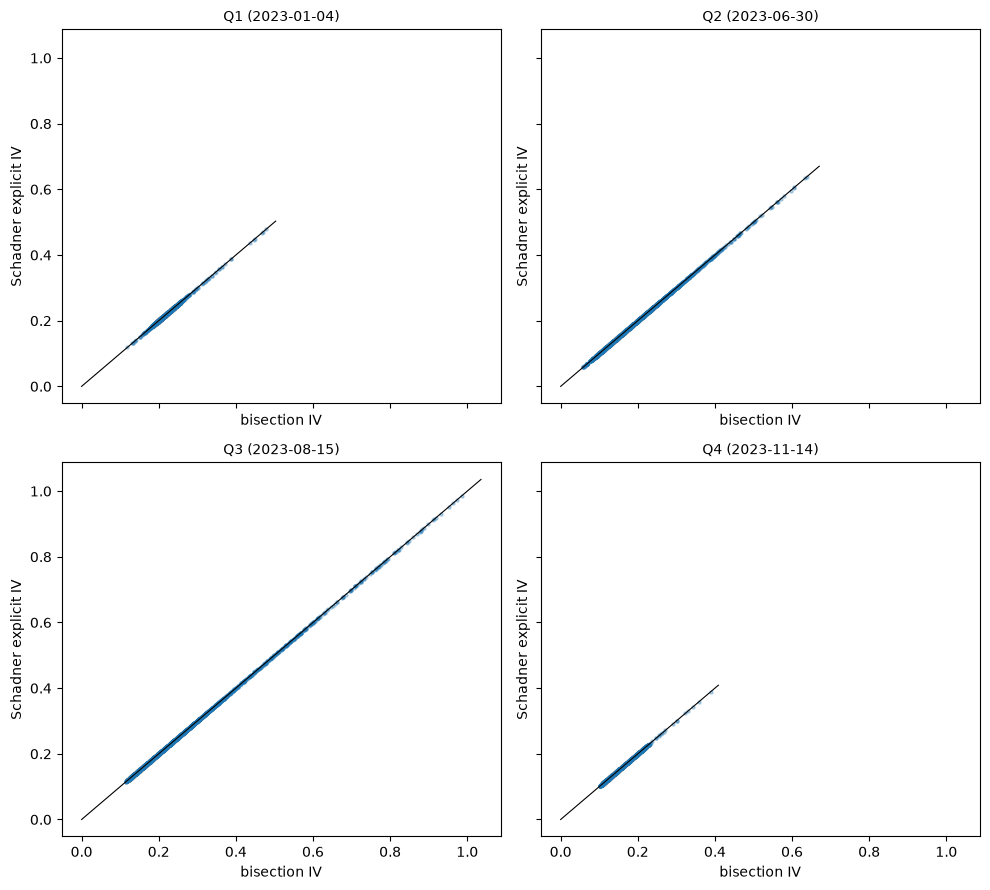

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, label in zip(axes.flat, FILES):
    subset = pairs[pairs["quarter"] == label]
    ax.scatter(subset["bisection_iv"], subset["schadner_iv"], s=5, alpha=0.3)
    lims = [0, subset[["bisection_iv", "schadner_iv"]].max().max() * 1.05]
    ax.plot(lims, lims, color="black", linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("bisection IV")
    ax.set_ylabel("Schadner explicit IV")
fig.tight_layout()

## Known fragility: scipy's `invgauss.ppf` outside this dataset's range

A broad synthetic stress test (random strikes, maturities from 4 days to 2 years, vols from 2% to 150%) found that `scipy.stats.invgauss.ppf` silently returns a badly wrong quantile — not a NaN — for a small share of combinations where total volatility $v = \sigma\sqrt{T}$ is very small *and* the option is away from the money. This is scipy's generic Boost-based root-finder struggling, not a flaw in the formula itself (the paper's own point is that variance is the *better*-conditioned coordinate; their custom implementation handles it, scipy's generic one doesn't always). On this notebook's actual SPX data, this never triggers — confirmed above by zero rows exceeding a $10^{-4}$ disagreement with bisection. The cell below reproduces the failure mode on synthetic inputs so it's not just an asserted claim.

In [11]:
rng = np.random.default_rng(0)
synthetic_errors = []
for _ in range(2000):
    spot = 4000.0
    strike = spot * rng.uniform(0.5, 1.6)
    time_to_expiry = rng.uniform(0.01, 2.0)
    true_vol = rng.uniform(0.02, 1.5)
    price = black_scholes_call(spot, strike, time_to_expiry, true_vol, risk_free_rate, dividend_yield)
    recovered = implied_volatility_schadner(price, spot, strike, time_to_expiry, risk_free_rate, dividend_yield)
    if np.isfinite(recovered):
        synthetic_errors.append(abs(recovered - true_vol))

synthetic_errors = np.array(synthetic_errors)
print(f"Synthetic stress test: {len(synthetic_errors):,} cases")
print(f"Median abs error: {np.median(synthetic_errors):.3e}")
print(f"Cases with error > 1e-6: {(synthetic_errors > 1e-6).sum()} "
      f"({(synthetic_errors > 1e-6).mean():.1%})")
print(f"Max error observed: {synthetic_errors.max():.3f}")

Synthetic stress test: 2,000 cases
Median abs error: 3.331e-16
Cases with error > 1e-6: 51 (2.5%)
Max error observed: 0.217


/Users/maxwellcheng/python/fim500project/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:5106: RuntimeWarning: Error in function boost::math::quantile(const inverse_gaussian_distribution<d>&, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  ppf = np.asarray(scu._invgauss_ppf(x, mu, 1))
